# <font color='blue'> Medical Insurance Cost </font>

The dataset for this study was downloaded from **Kaggle** ([link](https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset/data))

## <font color='purple'> Description of Dataset </font>

This dataset contains medical insurance cost information for 1338 individuals. It includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US. The target variable is charges, which represents the medical insurance cost billed to the individual.

### <font color='blue'> Data Columns </font>

- **age:** Age of primary beneficiary (`int`)

- **sex:** Gender of beneficiary (`male`, `female`)

- **bmi:** Body Mass Index, a measure of body fat based on height and weight (`float`)

- **children:** Number of children covered by health insurance (`int`)

- **smoker:** Smoking status of the beneficiary (`yes`, `no`)

- **region:** Residential region in the US (`northeast`, `northwest`, `southeast`, `southwest`)

- **charges:** Medical insurance cost billed to the beneficiary (`float`)

## <font color='orange'> Loading Dataset and Preprocessing </font>

In [3]:
# load the data
import pandas as pd

df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# finding null entries

null_columns = df.isnull().sum()
print(null_columns)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
# description of data
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## <font color='orange'> Distribution of Variables </font>

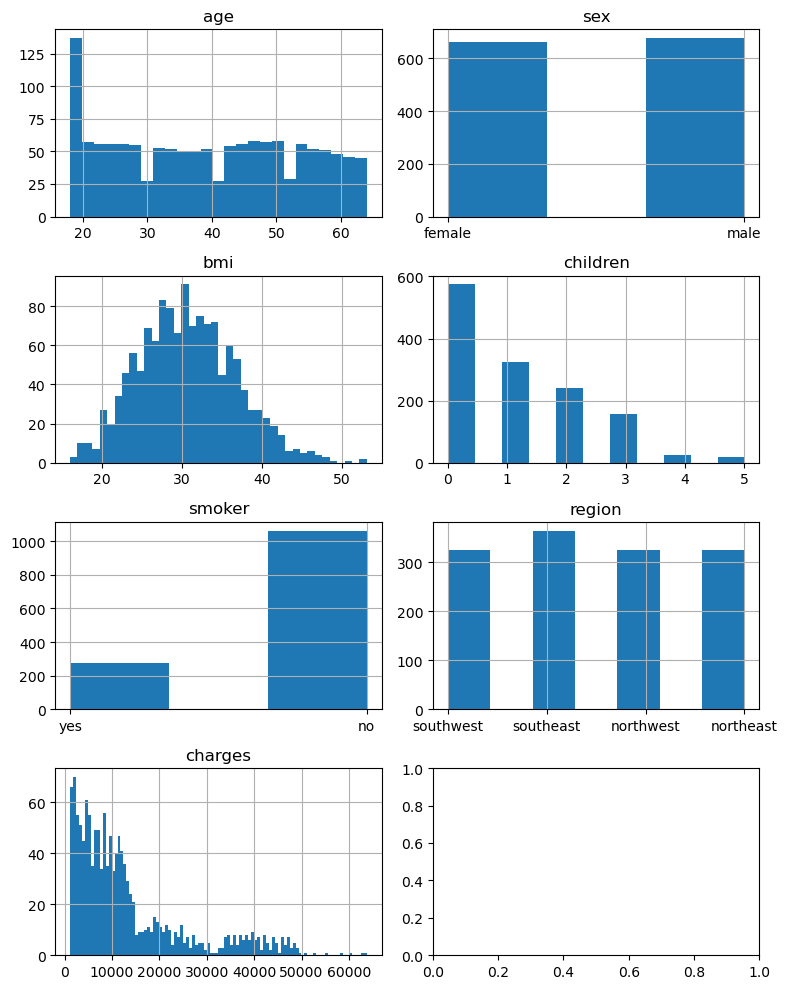

In [34]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10))

 	 	 	 	 	

df['age'].hist(bins=25, ax=axes[0,0])
axes[0,0].set_title('age')


df['sex'].hist(bins=3, ax=axes[0,1])
axes[0,1].set_title('sex')


df['bmi'].hist(bins=40, ax=axes[1,0])
axes[1,0].set_title('bmi')


df['children'].hist(bins=11, ax=axes[1,1])
axes[1,1].set_title('children')


df['smoker'].hist(bins=3, ax=axes[2,0])
axes[2,0].set_title('smoker')


df['region'].hist(bins=7, ax=axes[2,1])
axes[2,1].set_title('region')


df['charges'].hist(bins=100, ax=axes[3,0])
axes[3,0].set_title('charges')

 	 	
plt.tight_layout()
plt.savefig("../figures/variable_distributions.pdf")
plt.show()

## <font color='orange'> Insurance Cost vs Other Variables </font>

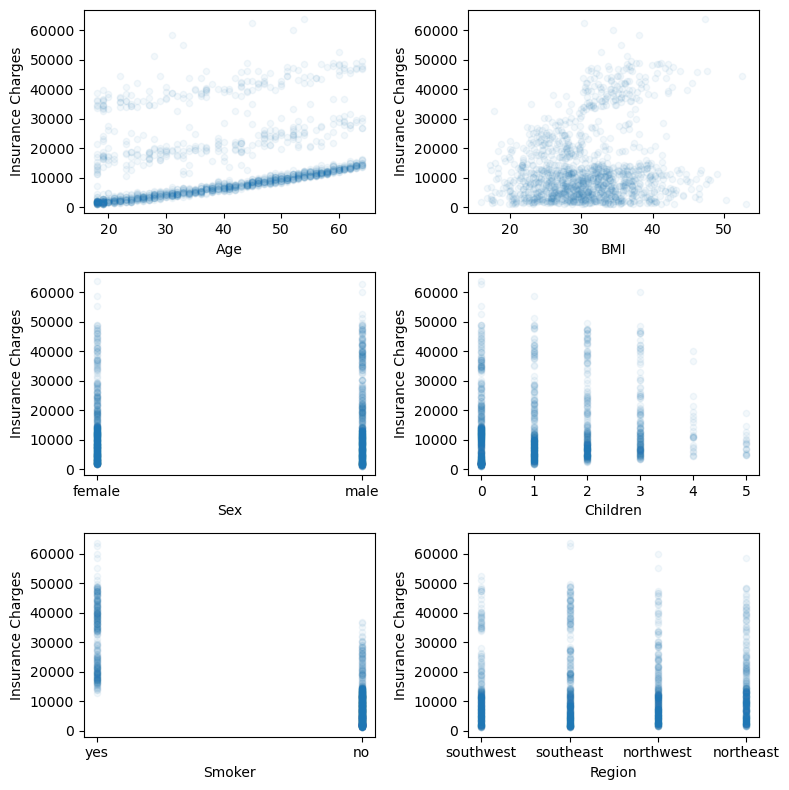

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8))


df.plot(kind='scatter', x='age', y='charges', ax=axes[0,0], alpha=0.05)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Insurance Charges')


df.plot(kind='scatter', x='bmi', y='charges', ax=axes[0,1], alpha=0.05)
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Insurance Charges')


df.plot(kind='scatter', x='sex', y='charges', ax=axes[1,0], alpha=0.05)
axes[1,0].set_xlabel('Sex')
axes[1,0].set_ylabel('Insurance Charges')


df.plot(kind='scatter', x='children', y='charges', ax=axes[1,1], alpha=0.05)
axes[1,1].set_xlabel('Children')
axes[1,1].set_ylabel('Insurance Charges')


df.plot(kind='scatter', x='smoker', y='charges', ax=axes[2,0], alpha=0.05)
axes[2,0].set_xlabel('Smoker')
axes[2,0].set_ylabel('Insurance Charges')


df.plot(kind='scatter', x='region', y='charges', ax=axes[2,1], alpha=0.05)
axes[2,1].set_xlabel('Region')
axes[2,1].set_ylabel('Insurance Charges')


plt.tight_layout()
plt.savefig("../figures/insurance_cost_vs_variables.pdf")
plt.show()

### There seems to be no variable strongly correlated to Insurance charges.

## <font color='orange'> Corrrelation of Variables </font>

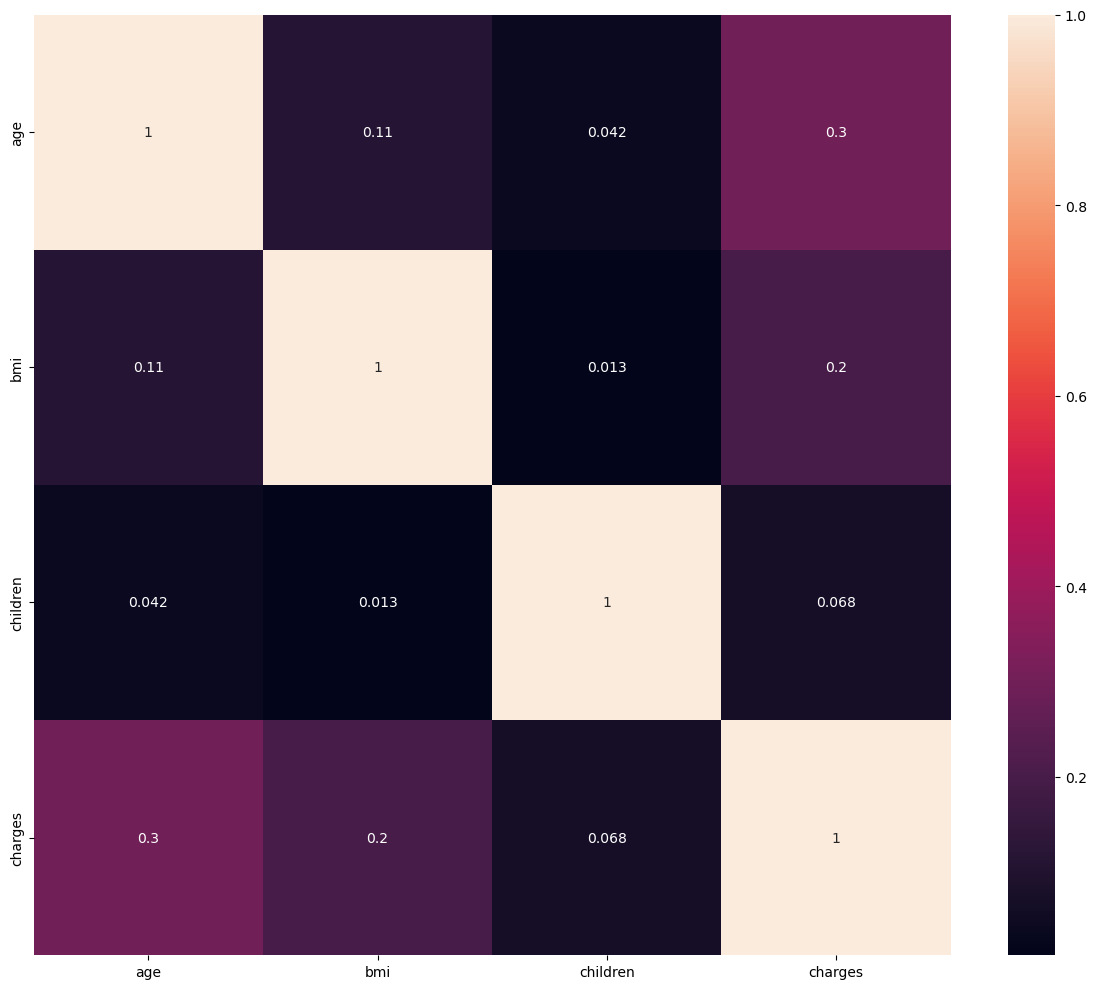

In [44]:
import seaborn as sns

corr_df = df.drop(['sex', 'smoker', 'region'],  axis='columns')
corr = corr_df.corr(method='pearson')

plt.figure(figsize=(12, 10))

ax = sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.savefig("../figures/variable_correlations.pdf")
plt.show()

### This verifies that no single variable is strongly correlated to Insurance charges.